# Mini Project — Deteksi Keberadaan Tanda Tangan

**Tujuan:** mendeteksi `SIGNATURE PRESENT` atau `SIGNATURE ABSENT` melalui crop ROI, grayscale, global threshold, Otsu threshold, morphological opening & closing, serta perhitungan piksel foreground.

> Catatan: seluruh citra present berasal dari dataset tugas. Karena dataset awal hanya berisi citra bertanda tangan, folder `data/test_absent` berisi sampel negatif terkontrol yang dibuat dengan mengosongkan ROI tanda tangan dari beberapa citra.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IMAGE_DIR = "data/images"
ABSENT_DIR = "data/test_absent"
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULT_DIR, "global"), exist_ok=True)
os.makedirs(os.path.join(RESULT_DIR, "otsu"), exist_ok=True)

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 1. Menentukan Dataset

Dataset dibagi menjadi dua kelompok:
- **PRESENT:** citra yang memiliki tanda tangan.
- **ABSENT:** citra tanpa tanda tangan untuk pengujian negatif.

In [2]:
def list_images(folder):
    if not os.path.exists(folder):
        return []
    return sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

present_files = list_images(IMAGE_DIR)
absent_files = list_images(ABSENT_DIR)

print(f"Citra PRESENT: {len(present_files)}")
for f in present_files: print(" -", f)
print(f"\nCitra ABSENT: {len(absent_files)}")
for f in absent_files: print(" -", f)

Citra PRESENT: 9
 - 01_HighQuality_Enhanced.jpg
 - 02_LowContrast.jpg
 - 03_Blurred.jpg
 - 04_HighNoise.jpg
 - 05_LowResolution_Upsampled.jpg
 - 06_Faded_Underexposed.jpg
 - 07_ColorShift_WarmTint.jpg
 - 08_JPEGCompression_Artifacts.jpg
 - 09_CombinedDegradation.jpg

Citra ABSENT: 5
 - absent_01.jpg
 - absent_02.jpg
 - absent_03.jpg
 - absent_04.jpg
 - absent_05.jpg


## 2. Menampilkan Citra Asli

Tahap ini digunakan untuk melihat seluruh sampel sebelum pengolahan.

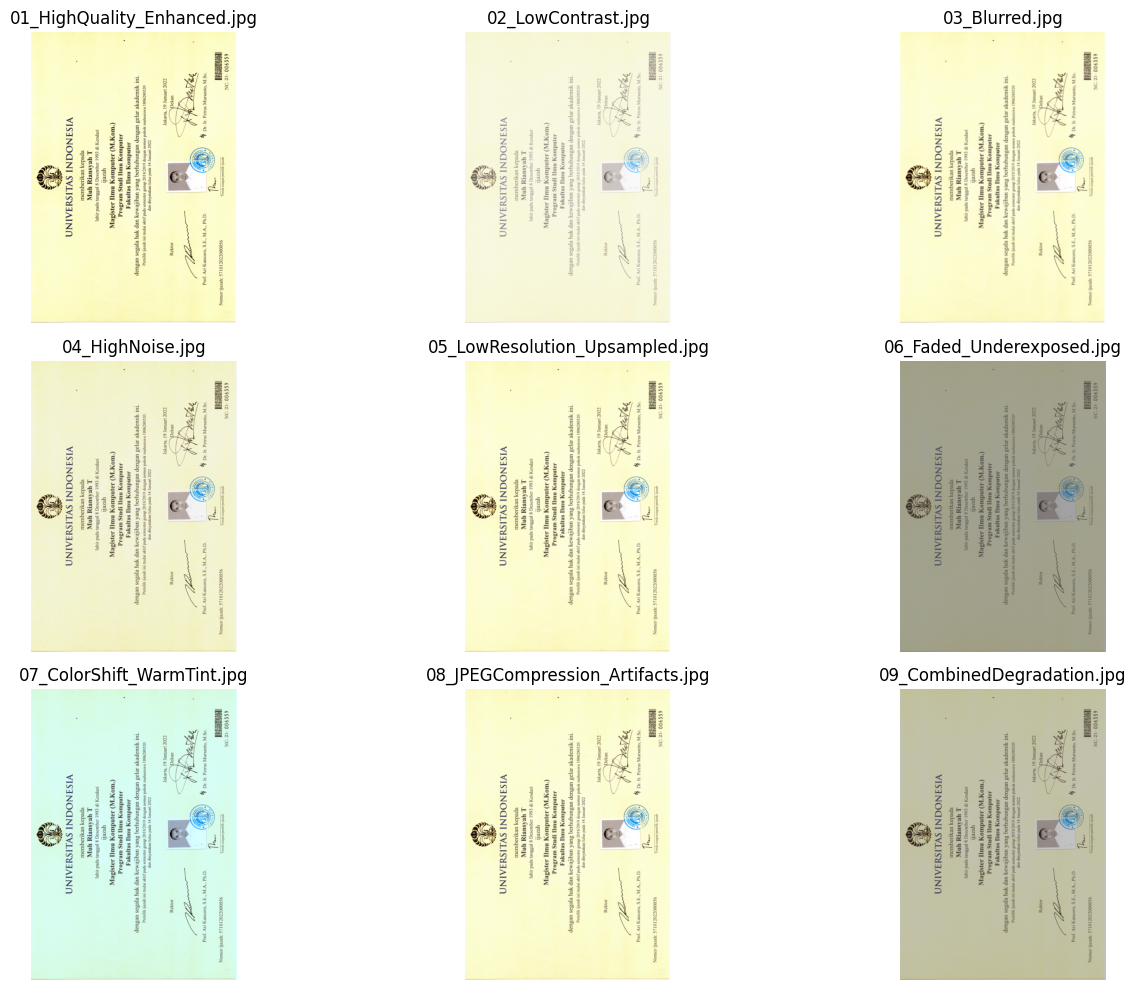

In [3]:
all_present = []
plt.figure(figsize=(15, 10))
for i, f in enumerate(present_files):
    img = cv2.imread(os.path.join(IMAGE_DIR, f))
    all_present.append(img)
    plt.subplot(3, 3, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Crop Area Tanda Tangan dan Grayscale

ROI mengikuti lokasi area tanda tangan pada dataset yang digunakan. Koordinat disimpan sebagai proporsi ukuran gambar agar dapat diterapkan pada seluruh citra dengan ukuran yang sama.

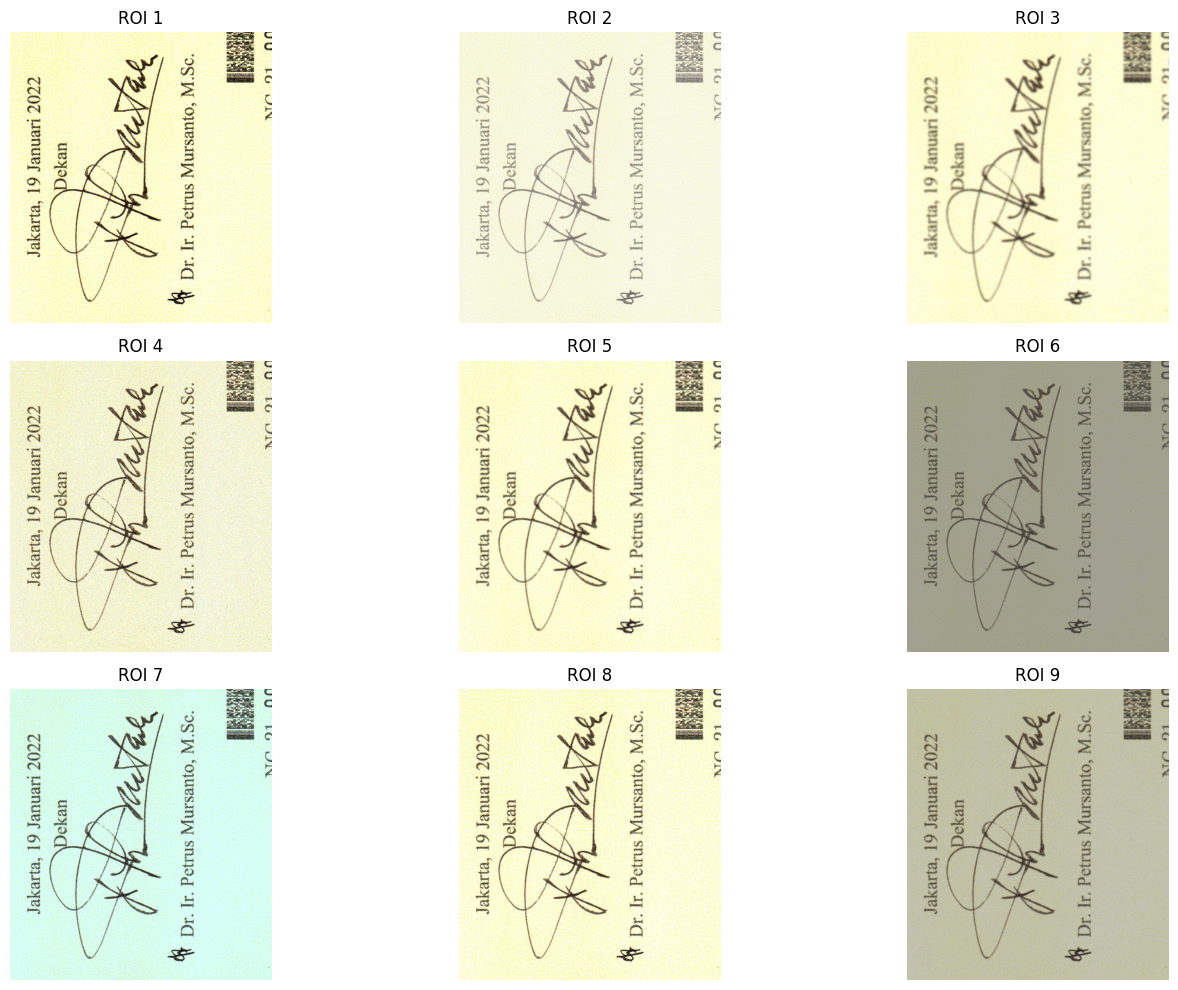

In [4]:
Y1, Y2 = 0.12, 0.38
X1, X2 = 0.62, 0.95

def crop_roi(img):
    h, w = img.shape[:2]
    return img[int(h*Y1):int(h*Y2), int(w*X1):int(w*X2)]

rois=[]
grays=[]
plt.figure(figsize=(15,10))
for i,f in enumerate(present_files):
    img=cv2.imread(os.path.join(IMAGE_DIR,f))
    roi=crop_roi(img)
    gray=cv2.cvtColor(roi,cv2.COLOR_BGR2GRAY)
    rois.append(roi); grays.append(gray)
    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(roi,cv2.COLOR_BGR2RGB))
    plt.title(f"ROI {i+1}")
    plt.axis("off")
plt.tight_layout(); plt.show()

## 4. Konversi Grayscale

Citra ROI diubah dari RGB/BGR menjadi grayscale agar setiap piksel memiliki satu nilai intensitas.

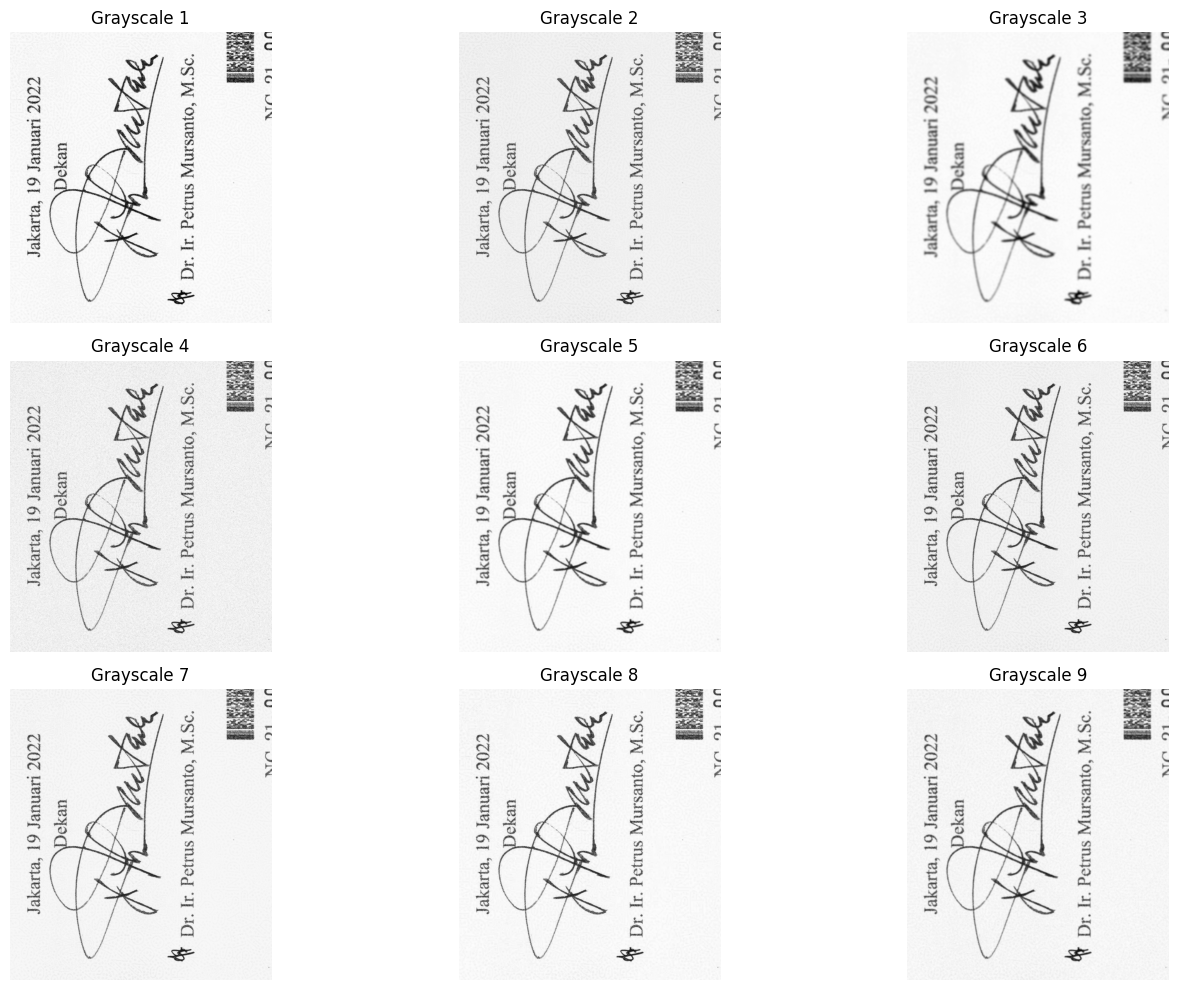

In [5]:
plt.figure(figsize=(15,10))
for i,gray in enumerate(grays):
    plt.subplot(3,3,i+1)
    plt.imshow(gray,cmap="gray")
    plt.title(f"Grayscale {i+1}")
    plt.axis("off")
plt.tight_layout(); plt.show()

## 5. Thresholding: Global dan Otsu

Dua metode utama dibandingkan:
- **Global threshold:** nilai ambang ditetapkan 180.
- **Otsu threshold:** nilai ambang ditentukan otomatis.

Nilai Otsu tiap citra: [159.0, 198.0, 199.0, 166.0, 183.0, 124.0, 165.0, 172.0, 145.0]


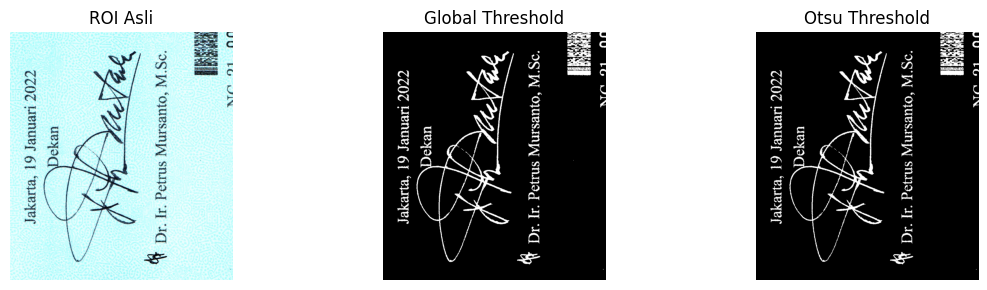

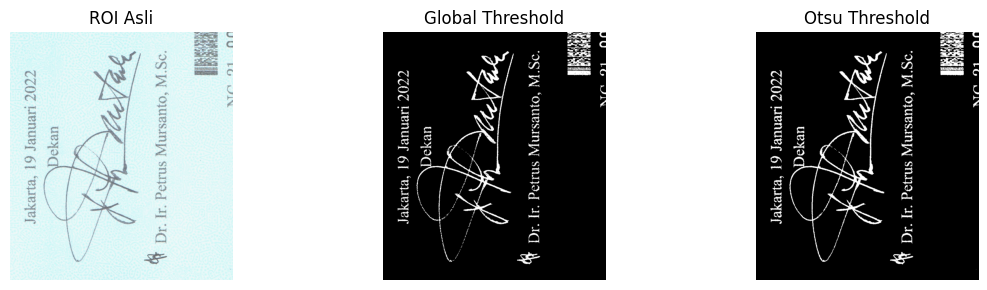

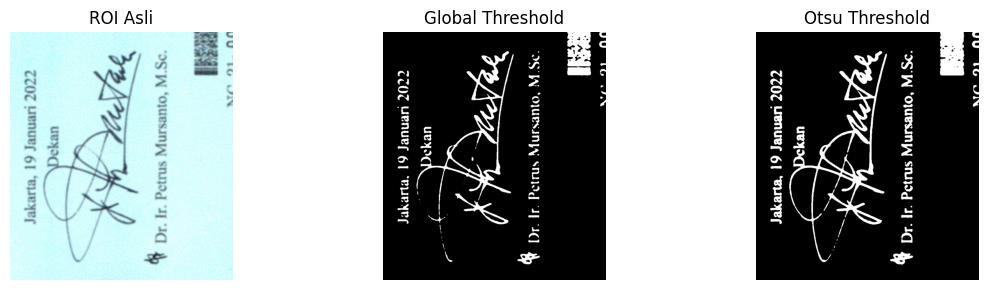

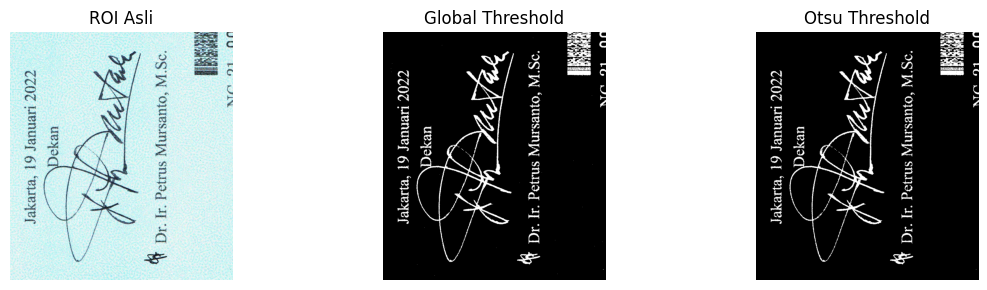

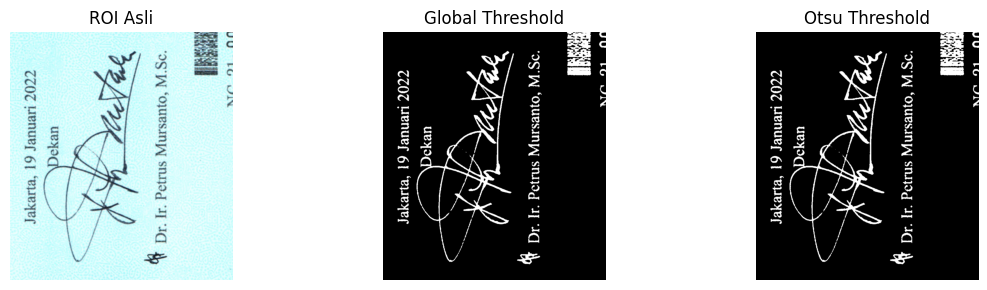

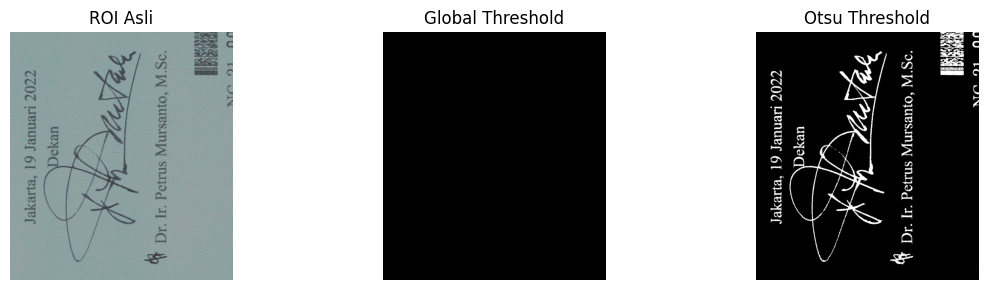

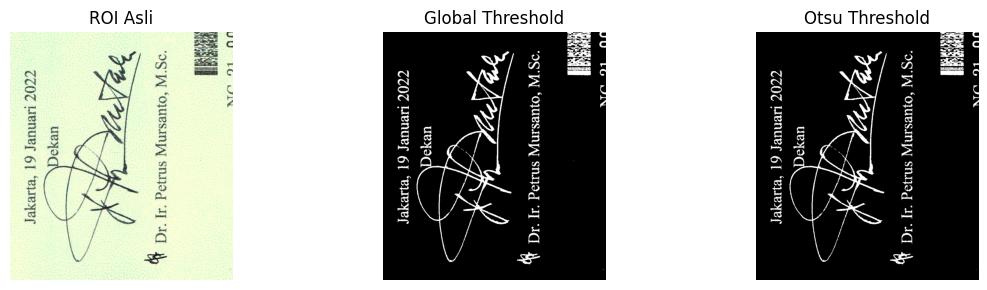

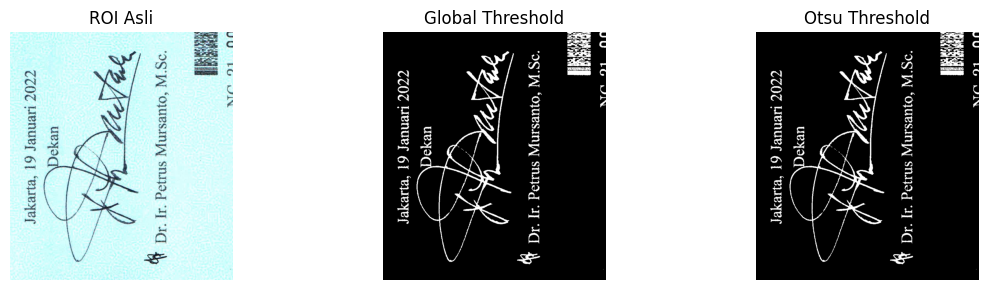

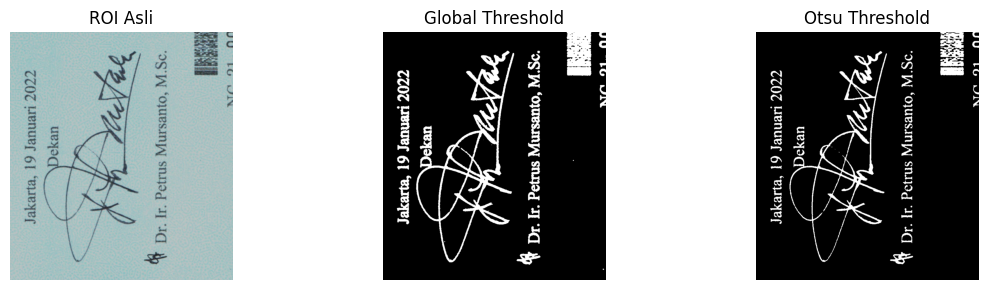

In [6]:
GLOBAL_THRESHOLD=180
otsu_values=[]
global_results=[]
otsu_results=[]

for gray in grays:
    _, g=cv2.threshold(gray,GLOBAL_THRESHOLD,255,cv2.THRESH_BINARY_INV)
    otsu_value,o=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    global_results.append(g); otsu_results.append(o); otsu_values.append(otsu_value)

print("Nilai Otsu tiap citra:", [round(x,2) for x in otsu_values])

for i in range(len(grays)):
    plt.figure(figsize=(12,3))
    plt.subplot(1,3,1); plt.imshow(rois[i]); plt.title("ROI Asli"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(global_results[i],cmap="gray"); plt.title("Global Threshold"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(otsu_results[i],cmap="gray"); plt.title("Otsu Threshold"); plt.axis("off")
    plt.tight_layout(); plt.show()

## 6. Morphological Opening dan Closing

Opening digunakan untuk mengurangi noise kecil. Closing digunakan untuk menyambungkan bagian foreground yang terputus.

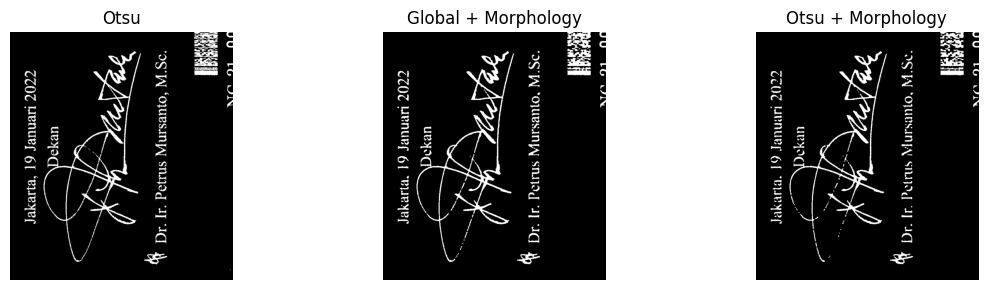

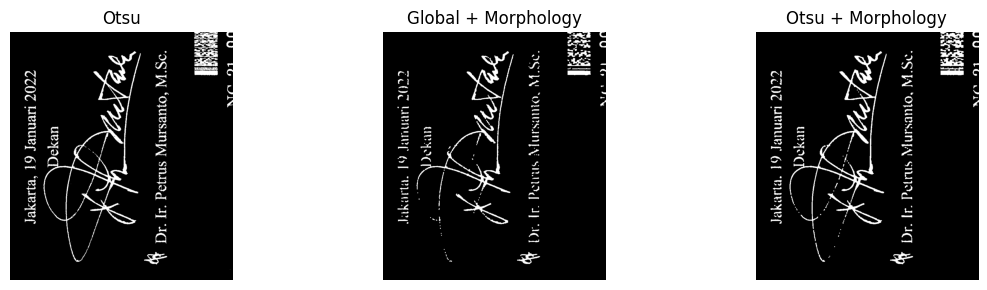

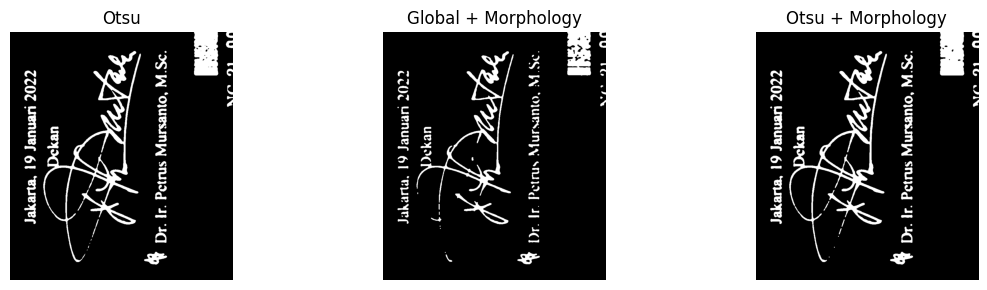

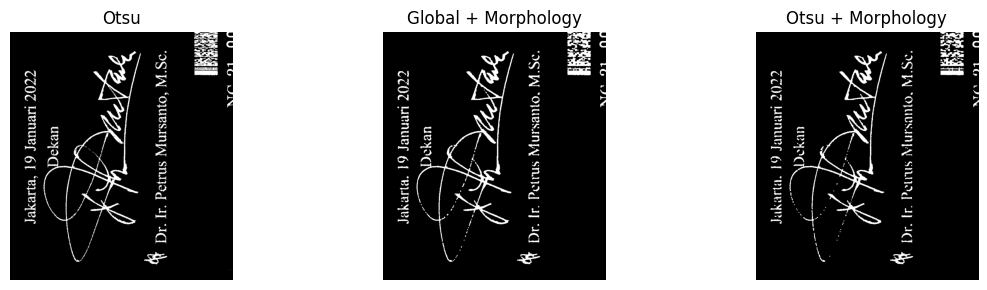

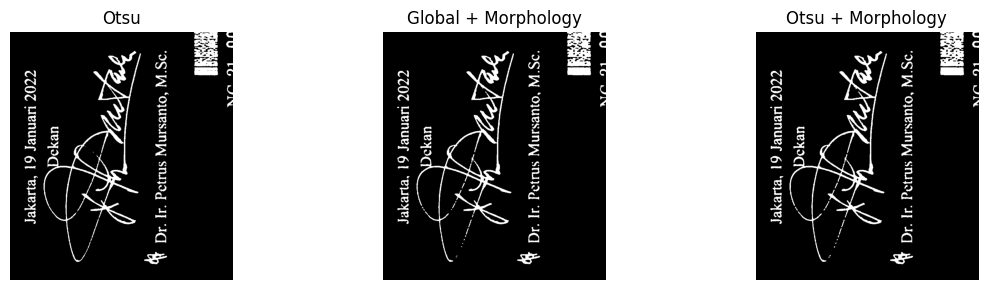

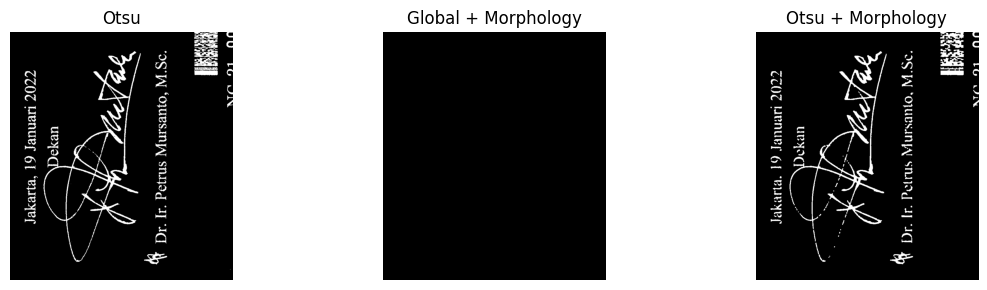

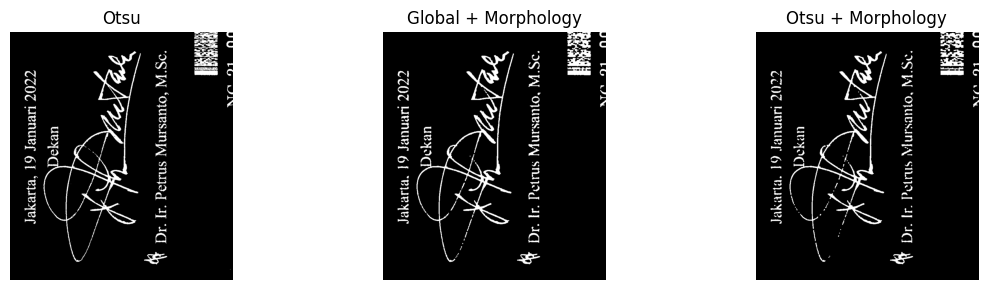

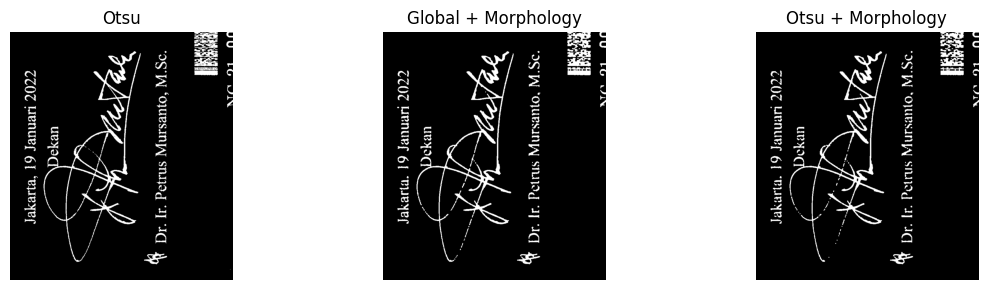

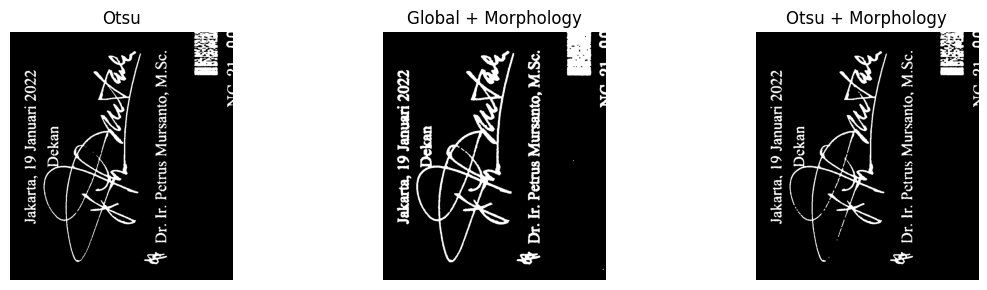

In [7]:
kernel=np.ones((3,3),np.uint8)

def morphology(binary):
    opening=cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel)
    closing=cv2.morphologyEx(opening,cv2.MORPH_CLOSE,kernel)
    return closing

global_clean=[morphology(x) for x in global_results]
otsu_clean=[morphology(x) for x in otsu_results]

for i in range(len(grays)):
    plt.figure(figsize=(12,3))
    plt.subplot(1,3,1); plt.imshow(otsu_results[i],cmap="gray"); plt.title("Otsu"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(global_clean[i],cmap="gray"); plt.title("Global + Morphology"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(otsu_clean[i],cmap="gray"); plt.title("Otsu + Morphology"); plt.axis("off")
    plt.tight_layout(); plt.show()

## 7. Karakteristik Area dan Aturan Keputusan

Karakteristik yang dihitung adalah **jumlah piksel foreground** dan **foreground ratio**.

Aturan sederhana yang digunakan untuk seluruh citra:

`foreground ratio > 0.03` → **SIGNATURE PRESENT**

`foreground ratio <= 0.03` → **SIGNATURE ABSENT**

Nilai 0.03 berarti 3% area ROI merupakan foreground.

In [8]:
SIGNATURE_RATIO_THRESHOLD=0.03

def measure(binary):
    pixels=int(cv2.countNonZero(binary))
    ratio=pixels/binary.size
    status="SIGNATURE PRESENT" if ratio>SIGNATURE_RATIO_THRESHOLD else "SIGNATURE ABSENT"
    return pixels,ratio,status

rows=[]
for i,f in enumerate(present_files):
    gp,gr,_=measure(global_clean[i])
    op,orr,status=measure(otsu_clean[i])
    rows.append({"File":f,"Data":"PRESENT","Global_Foreground_Pixels":gp,"Global_Ratio":gr,"Otsu_Foreground_Pixels":op,"Otsu_Ratio":orr,"Detection":status,"Correct":status=="SIGNATURE PRESENT"})

# tampilkan ringkasan present
df_present=pd.DataFrame(rows)
display(df_present)

,File,Data,Global_Foreground_Pixels,Global_Ratio,Otsu_Foreground_Pixels,Otsu_Ratio,Detection,Correct
0,01_HighQuality_Enhanced.jpg,PRESENT,52682,0.070618,47897,0.064204,SIGNATURE PRESENT,True
1,02_LowContrast.jpg,PRESENT,39243,0.052603,48412,0.064894,SIGNATURE PRESENT,True
2,03_Blurred.jpg,PRESENT,57912,0.077628,76853,0.103018,SIGNATURE PRESENT,True
3,04_HighNoise.jpg,PRESENT,50590,0.067814,46239,0.061981,SIGNATURE PRESENT,True
4,05_LowResolution_Upsampled.jpg,PRESENT,57768,0.077435,59329,0.079528,SIGNATURE PRESENT,True
5,06_Faded_Underexposed.jpg,PRESENT,746016,1.000000,49191,0.065938,SIGNATURE PRESENT,True
6,07_ColorShift_WarmTint.jpg,PRESENT,52786,0.070757,48526,0.065047,SIGNATURE PRESENT,True
7,08_JPEGCompression_Artifacts.jpg,PRESENT,52470,0.070334,49796,0.066749,SIGNATURE PRESENT,True
8,09_CombinedDegradation.jpg,PRESENT,84818,0.113695,56689,0.075989,SIGNATURE PRESENT,True


## 8. Pengujian Citra Tanpa Tanda Tangan

Citra pada `data/test_absent` diproses dengan ROI, grayscale, global threshold, Otsu, dan morphology yang **sama**. Tidak ada threshold keputusan baru untuk citra absent.

In [9]:
absent_rows=[]
for f in absent_files:
    img=cv2.imread(os.path.join(ABSENT_DIR,f))
    roi=crop_roi(img)
    gray=cv2.cvtColor(roi,cv2.COLOR_BGR2GRAY)
    _,g=cv2.threshold(gray,GLOBAL_THRESHOLD,255,cv2.THRESH_BINARY_INV)
    _,o=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    gc=morphology(g); oc=morphology(o)
    gp,gr,_=measure(gc); op,orr,status=measure(oc)
    absent_rows.append({"File":f,"Data":"ABSENT","Global_Foreground_Pixels":gp,"Global_Ratio":gr,"Otsu_Foreground_Pixels":op,"Otsu_Ratio":orr,"Detection":status,"Correct":status=="SIGNATURE ABSENT"})

df_absent=pd.DataFrame(absent_rows)
display(df_absent)

,File,Data,Global_Foreground_Pixels,Global_Ratio,Otsu_Foreground_Pixels,Otsu_Ratio,Detection,Correct
0,absent_01.jpg,ABSENT,0,0.0,5182,0.006946,SIGNATURE ABSENT,True
1,absent_02.jpg,ABSENT,0,0.0,2027,0.002717,SIGNATURE ABSENT,True
2,absent_03.jpg,ABSENT,0,0.0,4538,0.006083,SIGNATURE ABSENT,True
3,absent_04.jpg,ABSENT,0,0.0,5665,0.007594,SIGNATURE ABSENT,True
4,absent_05.jpg,ABSENT,0,0.0,4480,0.006005,SIGNATURE ABSENT,True


## 9. Tabel Hasil Pengujian dan Perbandingan

Tabel berikut menggabungkan seluruh citra present dan absent. Selain hasil deteksi, ditampilkan jumlah piksel foreground untuk membandingkan segmentasi global dan Otsu.

In [10]:
df_all=pd.concat([df_present,df_absent],ignore_index=True)
df_all["Global_Ratio"]=df_all["Global_Ratio"].round(4)
df_all["Otsu_Ratio"]=df_all["Otsu_Ratio"].round(4)
display(df_all)

accuracy=df_all["Correct"].mean()*100
print(f"Akurasi sistem berdasarkan Otsu + morphology: {accuracy:.2f}%")
df_all.to_csv(os.path.join(RESULT_DIR,"detection_results.csv"),index=False)
print("CSV disimpan di results/detection_results.csv")

,File,Data,Global_Foreground_Pixels,Global_Ratio,Otsu_Foreground_Pixels,Otsu_Ratio,Detection,Correct
0,01_HighQuality_Enhanced.jpg,PRESENT,52682,0.0706,47897,0.0642,SIGNATURE PRESENT,True
1,02_LowContrast.jpg,PRESENT,39243,0.0526,48412,0.0649,SIGNATURE PRESENT,True
2,03_Blurred.jpg,PRESENT,57912,0.0776,76853,0.1030,SIGNATURE PRESENT,True
3,04_HighNoise.jpg,PRESENT,50590,0.0678,46239,0.0620,SIGNATURE PRESENT,True
4,05_LowResolution_Upsampled.jpg,PRESENT,57768,0.0774,59329,0.0795,SIGNATURE PRESENT,True
5,06_Faded_Underexposed.jpg,PRESENT,746016,1.0000,49191,0.0659,SIGNATURE PRESENT,True
6,07_ColorShift_WarmTint.jpg,PRESENT,52786,0.0708,48526,0.0650,SIGNATURE PRESENT,True
7,08_JPEGCompression_Artifacts.jpg,PRESENT,52470,0.0703,49796,0.0667,SIGNATURE PRESENT,True
8,09_CombinedDegradation.jpg,PRESENT,84818,0.1137,56689,0.0760,SIGNATURE PRESENT,True
9,absent_01.jpg,ABSENT,0,0.0000,5182,0.0069,SIGNATURE ABSENT,True


Akurasi sistem berdasarkan Otsu + morphology: 100.00%
CSV disimpan di results/detection_results.csv


## 10. Visualisasi Hasil Akhir

Contoh hasil segmentasi Otsu + morphology ditampilkan bersama status deteksi.

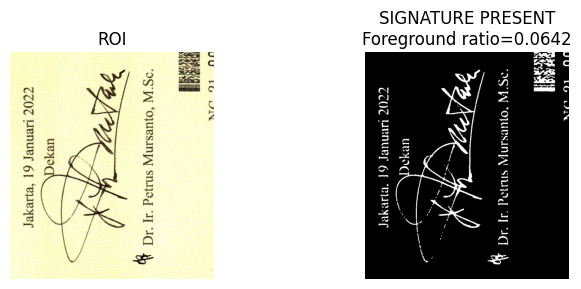

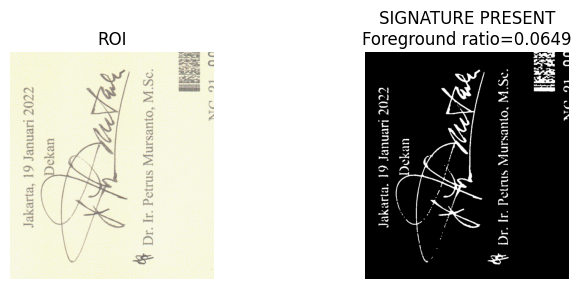

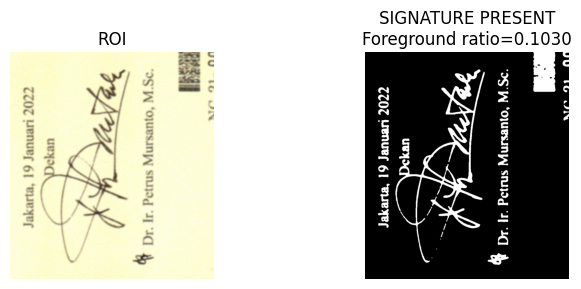

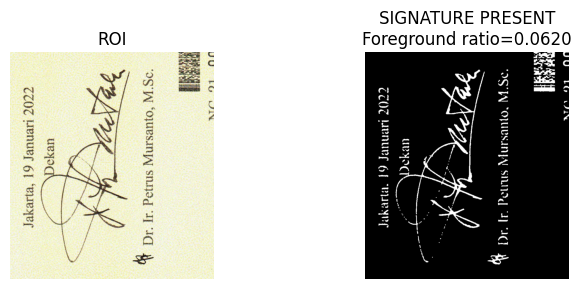

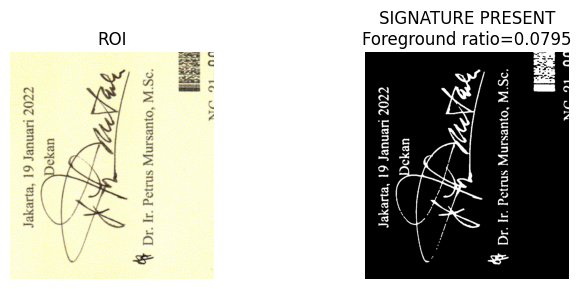

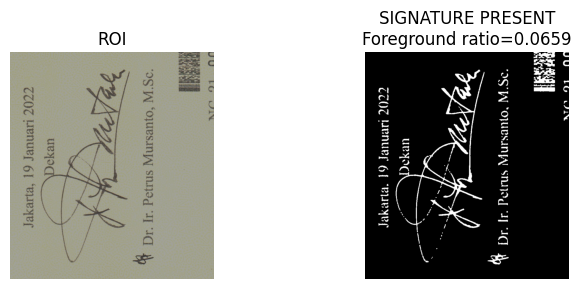

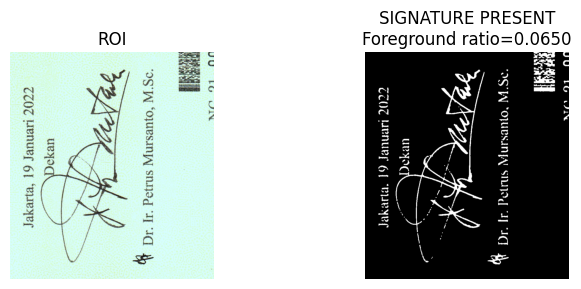

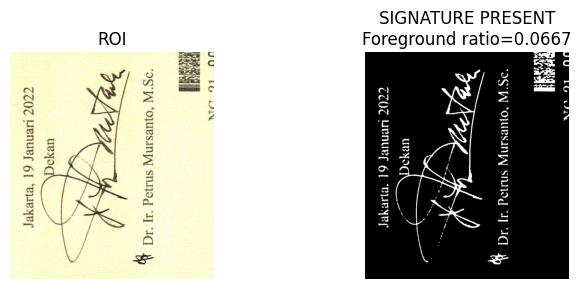

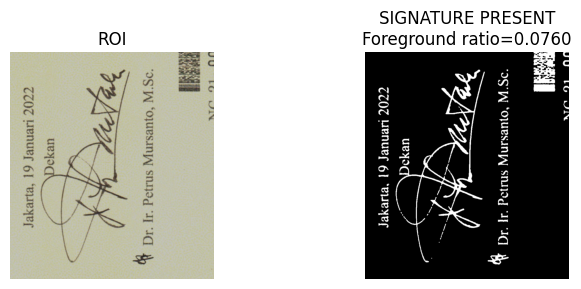

In [11]:
# Tampilkan seluruh hasil present
for i,f in enumerate(present_files):
    pixels,ratio,status=measure(otsu_clean[i])
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(rois[i],cv2.COLOR_BGR2RGB)); plt.title("ROI"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(otsu_clean[i],cmap="gray"); plt.title(f"{status}\nForeground ratio={ratio:.4f}"); plt.axis("off")
    plt.tight_layout(); plt.show()

## 11. Analisis

### Mengapa thresholding diperlukan sebelum analisis keberadaan tanda tangan?

Thresholding diperlukan untuk memisahkan area foreground yang mewakili goresan tanda tangan dari background. Setelah citra menjadi biner, jumlah piksel foreground dapat dihitung secara kuantitatif sehingga keberadaan tanda tangan dapat ditentukan menggunakan aturan sederhana.

### Apa masalah jika threshold terlalu tinggi atau terlalu rendah?

Jika threshold terlalu tinggi, terlalu banyak piksel background atau noise dapat masuk sebagai foreground sehingga area tanda tangan terlihat lebih besar dari kondisi sebenarnya. Jika threshold terlalu rendah, goresan tanda tangan yang tipis atau samar dapat hilang sehingga jumlah foreground terlalu kecil dan tanda tangan dapat salah dianggap tidak ada.

### Perbandingan Global dan Otsu

Global threshold menggunakan nilai ambang yang sama untuk semua citra sehingga sederhana tetapi sensitif terhadap perubahan pencahayaan dan kontras. Otsu menentukan ambang secara otomatis dari histogram masing-masing citra sehingga nilai ambangnya dapat berbeda antar citra. Pada project ini, kedua hasil dibandingkan melalui jumlah piksel foreground dan foreground ratio.